## Objective
Our goal is creating a simplified index, LRI (Lifestyle Risk Index), that can sufficiently predict cardiovascular disease..

In [312]:
import numpy as np
import pandas as pd
import seaborn as sb
import shap as sp
import matplotlib.pyplot as plt
sb.set()

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score, roc_auc_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [313]:
# Load the cardio dataset
cardiodata = pd.read_csv('cardio_train.csv', sep=';')
cardiodata.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [314]:
# inspect and clean the dataset
print("Original shape:", cardiodata.shape)
cardiodata.head()

Original shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [315]:
# Display information about the dataset
cardiodata.info()
print("\nDescriptive statistics of all columns:")
print(cardiodata.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Descriptive statistics of all columns:
               count          mean           std      min       25%      50%  \
id           70000.0  49972.419900  28851.302323      0.0  25006.75  50001.5   
age       

In [316]:
# Check missing values
print("Missing values per column:")
print(cardiodata.isnull().sum())
# No Missing Values

Missing values per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


### Exploratory Data Analysis
Finding the initial correlation between the different features to understand their relevance to CVD.

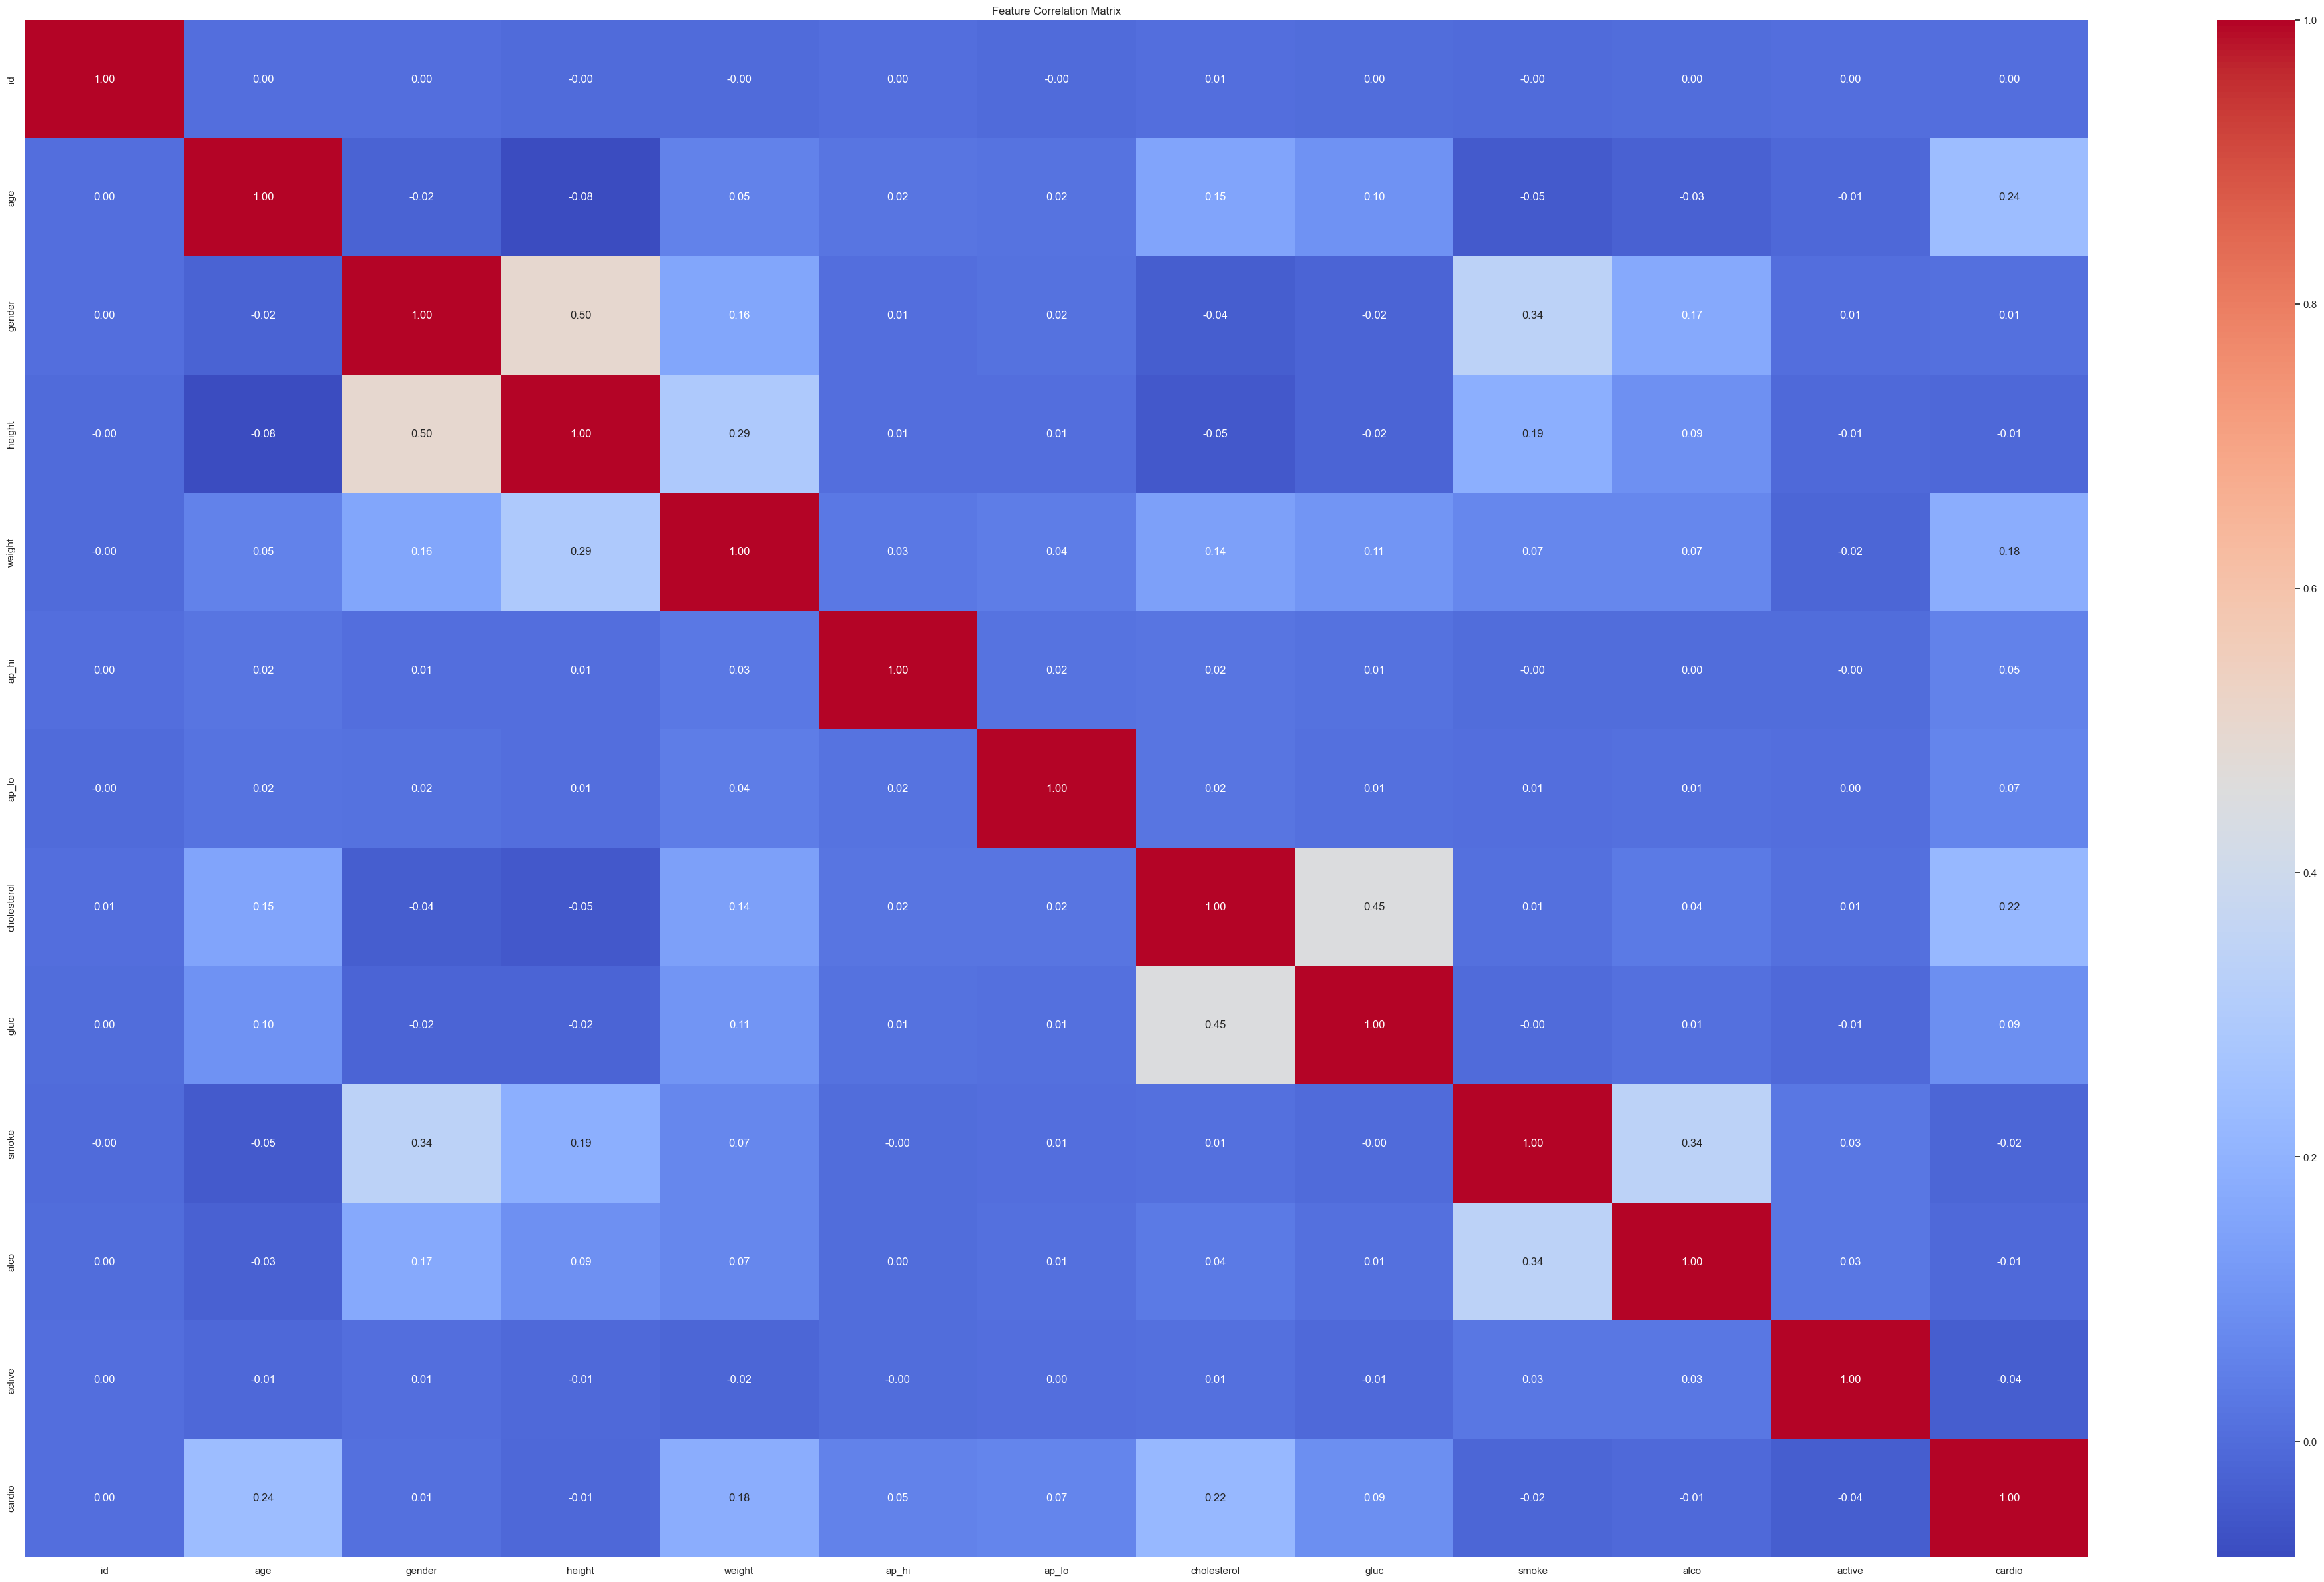

In [317]:
## Correlation Matrix
plt.figure(figsize=(50, 30))
sb.heatmap(cardiodata.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()
# Strong positive correlation between features like ap_hi and cardio indicates medical relevance (e.g., high BP → high CVD risk).

### Initial Findings & Cleaning the Data
##### By observing above, we found that systolic (ap_hi) and diastolic (ap_lo) blood pressure data had several issues:
- negative values
- ap_hi can be lower than ap_lo (impossible in real life)
- some blood pressure values go beyond world records

Thus we decided to perform cleaning of data to ensure reasonable numbers and to prevent errors.

In [318]:
#Remove rows where systolic <= diastolic (ap_hi <= ap_lo)
cardiodata = cardiodata[cardiodata['ap_hi'] > cardiodata['ap_lo']]
print("After removing rows with ap_hi <= ap_lo:", cardiodata.shape)

#Remove extreme ap_hi and ap_lo values based on world record numbers
cardiodata = cardiodata[(cardiodata['ap_hi'] >= 49) & (cardiodata['ap_hi'] <= 480)]
cardiodata = cardiodata[(cardiodata['ap_lo'] >= 25) & (cardiodata['ap_lo'] <= 370)]
print("After removing impossible BP values:", cardiodata.shape)

#Drop any duplicates
before = cardiodata.shape[0]
cardiodata = cardiodata.drop_duplicates()
print("Removed duplicates:", before - cardiodata.shape[0])

#Drop all NA rows
before = cardiodata.shape[0]
cardiodata = cardiodata.dropna()
print("Removed NA rows:", before - cardiodata.shape[0])

After removing rows with ap_hi <= ap_lo: (68764, 13)
After removing impossible BP values: (68679, 13)
Removed duplicates: 0
Removed NA rows: 0


### Improving the Data's Readability and other stuff
##### Some improvements and hypotheses could be made:
- **Age** can be converted to years for readability and for easier analysis
- We proposed **BMI** to act as another way to filter unrealistic data, and as a variable to replace height and weight
- We also proposed a new index, **LRI** (Lifestyle Risk Index) as a possible simplification to present data

In [319]:
# Convert age to years
cardiodata['age_years'] = (cardiodata['age'] / 365).round().astype(int)
print("Age (years) - min, max:", cardiodata['age_years'].min(), cardiodata['age_years'].max())

Age (years) - min, max: 30 65


In [320]:
# Compute BMI
cardiodata['height_m'] = cardiodata['height'] / 100.0
cardiodata['BMI'] = cardiodata['weight'] / (cardiodata['height_m'] ** 2)

print(cardiodata['BMI'].describe())

count    68679.000000
mean        27.521725
std          6.051494
min          3.471784
25%         23.875115
50%         26.346494
75%         30.119376
max        298.666667
Name: BMI, dtype: float64


In [321]:
#Remove extreme BMI values based on world record numbers
cardiodata = cardiodata[(cardiodata['BMI'] >= 7) & (cardiodata['BMI'] <= 250)]
print("After removing impossible BMI values:", cardiodata.shape)

After removing impossible BMI values: (68675, 16)


### Making Data Binary (Categorical)

We decided to simplify our data to a series of Risk Indexes, in order to create an equal weightage **LRI**.

We assign a value of '1' for postitive risk and value of '0' for no risk, for each risk factor in the dataset to get the artificial risk value of each risk factor.

We then assign different initial weights to each risk factor to make up the weighted LRI.

After that, we compare between using the data as is (cleaned version, not using our new indexes) vs using LRI.

In [322]:
# Engineer risk features
# BMI risk: 1 if BMI >= 30 (obese), else 0 
cardiodata['bmi_risk'] = (cardiodata['BMI'] >= 30).astype(int)

# High blood pressure: systolic >= 140 OR diastolic >= 90 (1 = high BP)
cardiodata['high_bp'] = ((cardiodata['ap_hi'] >= 140) | (cardiodata['ap_lo'] >= 90)).astype(int)

# Cholesterol risk: 1 if cholesterol > 1
cardiodata['chol_risk'] = (cardiodata['cholesterol'] > 1).astype(int)

# Glucose risk: 1 if glucose > 1
cardiodata['gluc_risk'] = (cardiodata['gluc'] > 1).astype(int)

# Lifestyle binary flags (smoke, alco, active) typically already 0/1 in dataset
# We define: smoke_risk: 1, alco_risk: 1, inactive_risk: 1 (active==1 => no risk)
cardiodata['smoke_risk'] = cardiodata['smoke'].astype(int)
cardiodata['alco_risk'] = cardiodata['alco'].astype(int)
cardiodata['inactive_risk'] = (cardiodata['active'] == 0).astype(int)

#Assign weights to each risk factor
weights = {
    'bmi_risk': 0.15,
    'high_bp': 0.25, #Strongest predictor since it is a major cause of heart disease, stroke
    'chol_risk': 0.2,
    'gluc_risk': 0.15,
    'smoke_risk': 0.1,
    'alco_risk': 0.05,
    'inactive_risk': 0.1
}

# check how many people are in each risk category, these are the columns that will form our LRI
LRI_PARTS = ['bmi_risk','high_bp','chol_risk','gluc_risk','smoke_risk','alco_risk','inactive_risk']
print(cardiodata[LRI_PARTS].sum())

bmi_risk         17979
high_bp          23547
chol_risk        17172
gluc_risk        10284
smoke_risk        6040
alco_risk         3664
inactive_risk    13505
dtype: int64


In [323]:
# Calculate Lifestyle Risk Index (LRI).The higher the value, the higher the overall risk.
cardiodata['LRI_weighted'] = (
    cardiodata['bmi_risk'] * weights['bmi_risk'] +
    cardiodata['high_bp'] * weights['high_bp'] +
    cardiodata['chol_risk'] * weights['chol_risk'] +
    cardiodata['gluc_risk'] * weights['gluc_risk'] +
    cardiodata['smoke_risk'] * weights['smoke_risk'] +
    cardiodata['alco_risk'] * weights['alco_risk'] +
    cardiodata['inactive_risk'] * weights['inactive_risk']
)

#Check results
cardiodata['LRI_weighted'] = cardiodata['LRI_weighted'].round(2)
print(cardiodata[['bmi_risk','high_bp','chol_risk','gluc_risk',
                  'smoke_risk','alco_risk','inactive_risk','LRI_weighted']].head(10))

#Summary statistics
print(cardiodata['LRI_weighted'].describe().round(2))


   bmi_risk  high_bp  chol_risk  gluc_risk  smoke_risk  alco_risk  \
0         0        0          0          0           0          0   
1         1        1          1          0           0          0   
2         0        0          1          0           0          0   
3         0        1          0          0           0          0   
4         0        0          0          0           0          0   
5         0        0          1          1           0          0   
6         1        0          1          0           0          0   
7         0        1          1          1           0          0   
8         0        0          0          0           0          0   
9         0        0          0          0           0          0   

   inactive_risk  LRI_weighted  
0              0          0.00  
1              0          0.60  
2              1          0.30  
3              0          0.25  
4              1          0.10  
5              1          0.45  
6        

In [324]:
# Save cleaned dataset for modelling
cardiodata.to_csv('cardio_cleaned.csv', index=False)
print(" Cleaned dataset saved as 'cardio_cleaned.csv'")

 Cleaned dataset saved as 'cardio_cleaned.csv'


In [325]:
cardio_cleaned = pd.read_csv('cardio_cleaned.csv')
print(cardio_cleaned.shape)
cardio_cleaned.head()

(68675, 24)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,...,height_m,BMI,bmi_risk,high_bp,chol_risk,gluc_risk,smoke_risk,alco_risk,inactive_risk,LRI_weighted
0,0,18393,2,168,62.0,110,80,1,1,0,...,1.68,21.967120,0,0,0,0,0,0,0,0.00
1,1,20228,1,156,85.0,140,90,3,1,0,...,1.56,34.927679,1,1,1,0,0,0,0,0.60
2,2,18857,1,165,64.0,130,70,3,1,0,...,1.65,23.507805,0,0,1,0,0,0,1,0.30
3,3,17623,2,169,82.0,150,100,1,1,0,...,1.69,28.710479,0,1,0,0,0,0,0,0.25
4,4,17474,1,156,56.0,100,60,1,1,0,...,1.56,23.011177,0,0,0,0,0,0,1,0.10


In [326]:
# Redundant columns
REDUNDANCIES = ['cardio', 'id', 'age', 'height', 'BMI']
BASE_CASE_VARS = ['weight', 'height_m', 'smoke', 'alco', 'active', 'cholesterol', 'gluc', 'BMI', 'ap_hi', 'ap_lo']
# LRI_PARTS = ['bmi_risk','high_bp','chol_risk','gluc_risk','smoke_risk','alco_risk','inactive_risk']

#Splitting baseline(without LRI, with risk parts that make up LRI) and enhanced(with LRI, without risk parts)
cols = cardio_cleaned.columns.tolist()
feature_cols_baseline = []

for c in cols:
    if c not in ['LRI_weighted'] + LRI_PARTS + REDUNDANCIES:
        feature_cols_baseline.append(c)
        
feature_cols_enhanced = []
for c in cols:
    if c not in BASE_CASE_VARS + LRI_PARTS + REDUNDANCIES:
        feature_cols_enhanced.append(c)

BASE_COLS = feature_cols_baseline.copy()
ENH_COLS  = feature_cols_enhanced.copy()

print("Baseline Variables:", feature_cols_baseline) #without LRI
print("Enhanced Variables:", feature_cols_enhanced) #with LRI
overlap = set(feature_cols_baseline).intersection(feature_cols_enhanced)
print("Overlap count:", len(overlap))

Baseline Variables: ['gender', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'height_m']
Enhanced Variables: ['gender', 'age_years', 'LRI_weighted']
Overlap count: 2


In [327]:
#Splitting baseline(without LRI, with risk parts that make up LRI) 
cardio_cleaned[feature_cols_baseline].head()

,gender,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,height_m
0,2,62.0,110,80,1,1,0,0,1,50,1.68
1,1,85.0,140,90,3,1,0,0,1,55,1.56
2,1,64.0,130,70,3,1,0,0,0,52,1.65
3,2,82.0,150,100,1,1,0,0,1,48,1.69
4,1,56.0,100,60,1,1,0,0,0,48,1.56


In [328]:
#Enhanced(with LRI, without risk parts)
cardio_cleaned[feature_cols_enhanced].head()

,gender,age_years,LRI_weighted
0,2,50,0.00
1,1,55,0.60
2,1,52,0.30
3,2,48,0.25
4,1,48,0.10


### Training the 2 datasets (Cleaned & Enhanced) to test the accuracy of the LRI 

We split the 2 datasets (cleaned & enhanced) into train and test datasets, to test the accuracy.

In [329]:
#train/test split for Baseline and enhanced so its fair
idx_train, idx_test = train_test_split(
    cardio_cleaned.index,
    test_size=0.2,
    random_state=42, #random_state is used for reproducibility
    stratify=cardio_cleaned['cardio'] #while stratify is to prevent inbalance
)

#BASELINE training set
Xb_train = cardio_cleaned.loc[idx_train, feature_cols_baseline]
Xb_test  = cardio_cleaned.loc[idx_test,  feature_cols_baseline]
y_train  = cardio_cleaned.loc[idx_train, 'cardio']
y_test   = cardio_cleaned.loc[idx_test,  'cardio']

print("Baseline Train Set :", Xb_train.shape, y_train.shape)
print("Baseline Test Set  :", Xb_test.shape, y_test.shape)

#Enhanced training set
Xe_train = cardio_cleaned.loc[idx_train, feature_cols_enhanced]
Xe_test  = cardio_cleaned.loc[idx_test,  feature_cols_enhanced]

print("Enhanced Train Set :", Xe_train.shape, y_train.shape)
print("Enhanced Test Set  :", Xe_test.shape, y_test.shape)

Baseline Train Set : (54940, 11) (54940,)
Baseline Test Set  : (13735, 11) (13735,)
Enhanced Train Set : (54940, 3) (54940,)
Enhanced Test Set  : (13735, 3) (13735,)


In [330]:
Xb_train = Xb_train.reindex(columns=BASE_COLS)
Xb_test  = Xb_test.reindex(columns=BASE_COLS)

Xe_train = Xe_train.reindex(columns=ENH_COLS)
Xe_test  = Xe_test.reindex(columns=ENH_COLS)

In [331]:
#function for finding threshold and then evalute
def eval_model(X_train, y_train, X_test, y_test, label,
                     max_depth=6, class_weight=None,
                     metric="accuracy", thres_grid=np.linspace(0.2, 0.8, 61)):
    
    #split train so that wont touch test
    idx_train2, idx_value = train_test_split(
        X_train.index,
        test_size=0.25,
        random_state=42,
        stratify=y_train
    )
    X_train2, y_train2 = X_train.loc[idx_train2], y_train.loc[idx_train2]
    X_value, y_value = X_train.loc[idx_value], y_train.loc[idx_value]

    #decision tree classifier
    DT = DecisionTreeClassifier(max_depth=max_depth, class_weight=class_weight, random_state=42)
    DT.fit(X_train2, y_train2)
    p_value = DT.predict_proba(X_value)[:,1]

    #try threshold from 0.2 to 0.8 -> convert each t to labels and get accuracy
    scores = [accuracy_score(y_value, (p_value >= t).astype(int)) for t in thres_grid]
    best_thres = float(thres_grid[int(np.argmax(scores))])

    #evaluate on test once with chosen thres
    p_test = DT.predict_proba(X_test)[:,1]
    yhat_test = (p_test >= best_thres).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, yhat_test, average="binary")

    row = {
        "model": label,
        "threshold": best_thres,
        "accuracy": accuracy_score(y_test, yhat_test),
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc_score(y_test, p_test)  # AUC doesn't need threshold
    }
    return row, DT, yhat_test


In [332]:
# --- 1. Run both models using eval_model() ---
row_base, dt_base, yhat_base = eval_model(
    Xb_train, y_train, Xb_test, y_test,
    label="Baseline (no LRI)",
    max_depth=6, class_weight=None, metric="accuracy"
)

# === Train Decision Tree on Enhanced (LRI) Dataset ===
row_enhance, dt_enhance, yhat_enhance = eval_model(
    Xe_train, y_train, Xe_test, y_test,
    label="Enhanced(with LRI)",
    max_depth=6,
    class_weight=None,
    metric="accuracy"
)

# --- 2. Compute correlation between predicted probabilities and true labels ---
# For DecisionTreeClassifier, we use predict_proba() to get probabilities
p_base = dt_base.predict_proba(Xb_test)[:, 1]
p_enh = dt_enhance.predict_proba(Xe_test)[:, 1]

corr_base = np.corrcoef(p_base, y_test)[0, 1]
corr_enh = np.corrcoef(p_enh, y_test)[0, 1]

# --- 3. Build performance summary table ---
perf_df = pd.DataFrame([
    {
        "Model": "Baseline (no LRI)",
        "Accuracy": row_base["accuracy"],
        "Precision": row_base["precision"],
        "Recall": row_base["recall"],
        "F1-score": row_base["f1"],
        "ROC-AUC": row_base["roc_auc"],
        "Correlation (Pred vs True)": corr_base
    },
    {
        "Model": "Enhanced (with LRI)",
        "Accuracy": row_enhance["accuracy"],
        "Precision": row_enhance["precision"],
        "Recall": row_enhance["recall"],
        "F1-score": row_enhance["f1"],
        "ROC-AUC": row_enhance["roc_auc"],
        "Correlation (Pred vs True)": corr_enh
    }
])

# --- 4. Display formatted comparison ---
print("\n==============================")
print("📊 DECISION TREE PERFORMANCE COMPARISON")
print("==============================")
display(perf_df.round(4))


📊 DECISION TREE PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Correlation (Pred vs True)
0,Baseline (no LRI),0.7302,0.7597,0.6649,0.7092,0.790,0.5110
1,Enhanced (with LRI),0.7062,0.7040,0.7007,0.7023,0.759,0.4521


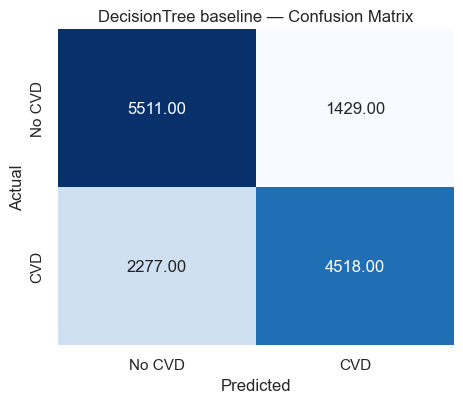

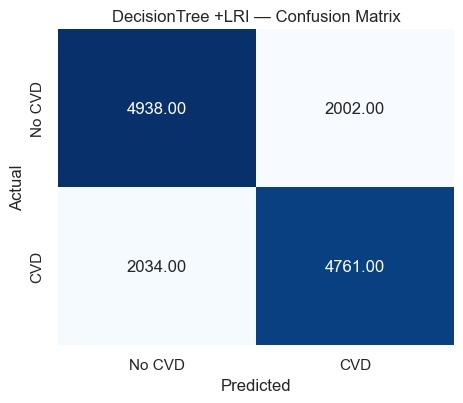

In [333]:
#printing out confusion matrix
plt.figure(figsize=(4.8, 4.2))
sb.heatmap(confusion_matrix(y_test, yhat_base),annot =True,fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=["No CVD","CVD"], yticklabels=["No CVD","CVD"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("DecisionTree baseline — Confusion Matrix")
plt.tight_layout(); plt.show()


plt.figure(figsize=(4.8, 4.2))
sb.heatmap(confusion_matrix(y_test, yhat_enhance),annot =True,fmt=".2f", cmap="Blues", cbar=False,
                xticklabels=["No CVD","CVD"], yticklabels=["No CVD","CVD"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("DecisionTree +LRI — Confusion Matrix")
plt.tight_layout(); plt.show()

### Decision Tree Analysis
- LRI performs very similarly to the base case, only being 6% less accurate.
- LRI is a significantly simpler and more efficient model to predict cardiovascular disease, being a reliable and more easily understandable indicator to explain to stakeholders compared to a complicated model.

Moving on, we will be assessing our model with SHAP.

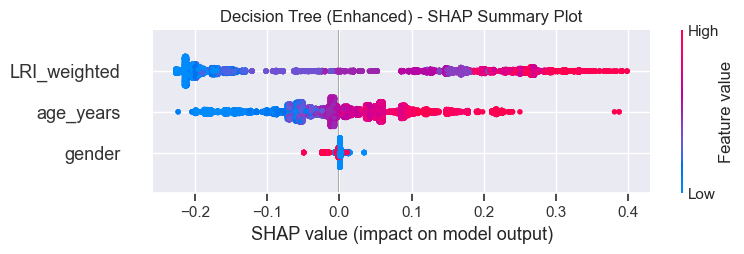

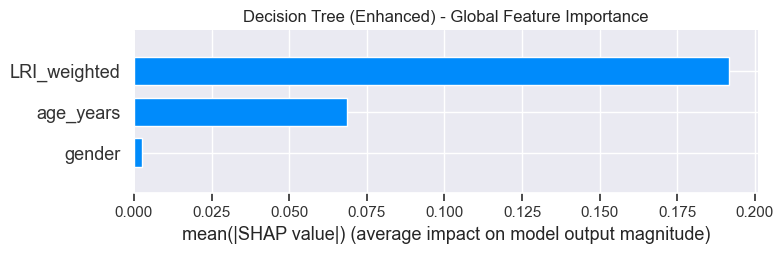

In [334]:
# 1. Initialize the explainer for our Decision Tree model
# (dt_enhance is the model trained on the 'enhanced' feature set)
explainer_dt = sp.TreeExplainer(dt_enhance)

# 2. Calculate the "Explanation" object
# This bundles SHAP values, data, and feature names
shap_explanations = explainer_dt(Xe_test)

# 3. Generate SHAP summary plot (beeswarm)
# We pass shap_explanations[:,:,1] to get the values for class 1 (CVD)
plt.title("Decision Tree (Enhanced) - SHAP Summary Plot")
sp.summary_plot(shap_explanations[:,:,1])
plt.show()

# 4. Generate SHAP feature importance plot (bar)
plt.title("Decision Tree (Enhanced) - Global Feature Importance")
sp.summary_plot(shap_explanations[:,:,1], plot_type="bar")
plt.show()


### LRI (Lifestyle Risk Index) – Top Feature
Higher LRI values (red dots) are mostly on the right side → this means that high LRI scores increase the model’s predicted risk.

Low LRI values (blue dots) are clustered around 0 or negative SHAP values → low lifestyle risk reduces the predicted risk.

✅ This validates that the LRI works as intended — higher lifestyle risk → higher chance of disease.

### Model Interpretability:
The Decision Tree model is behaving logically — SHAP confirms that it uses medically sound reasoning:

Higher LRI → higher disease risk

Higher age → higher disease risk

Gender → minor effect

### LRI Validation:
The fact that LRI dominates the SHAP plot means it’s a strong summary feature, capturing much of the lifestyle-related signal the model relies on.

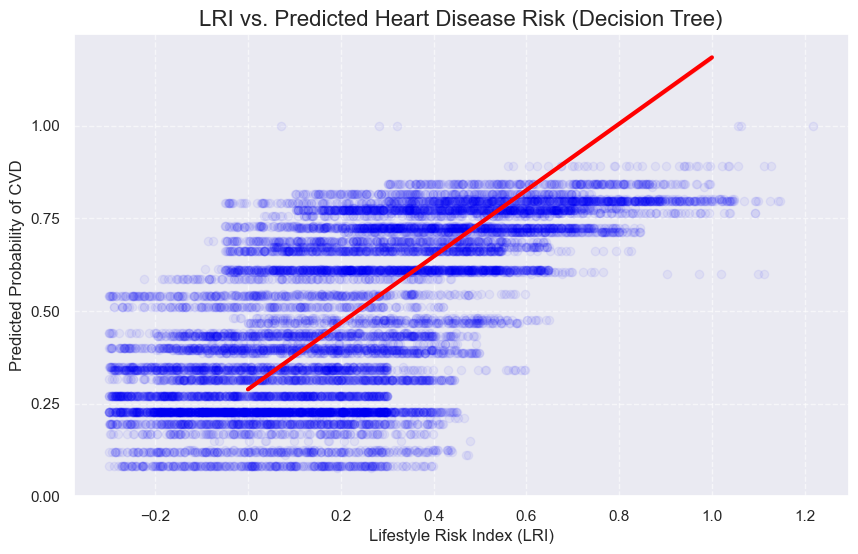

In [335]:
# 5. Visualize LRI vs. Predicted Heart Disease Risk

# Get the model's predicted probability for class 1 (CVD)
p_test_dt = dt_enhance.predict_proba(Xe_test)[:, 1]

# Create a new DataFrame for plotting
# The dataframe uses the column name 'LRI_weighted' in this notebook
plot_df = pd.DataFrame({
    'LRI': Xe_test['LRI_weighted'],
    'Predicted_Risk_DT': p_test_dt
})

# Use a regplot to visualize the relationship
plt.figure(figsize=(10, 6))

# We add x_jitter to see the density of points at each LRI level
sb.regplot(data=plot_df, x='LRI', y='Predicted_Risk_DT', x_jitter=0.3, 
           line_kws={'color': 'red', 'linewidth': 3}, 
           scatter_kws={'alpha': 0.05, 'color': 'blue'})
           
plt.title('LRI vs. Predicted Heart Disease Risk (Decision Tree)', fontsize=16)
plt.xlabel('Lifestyle Risk Index (LRI)', fontsize=12)
plt.ylabel('Predicted Probability of CVD', fontsize=12)
plt.yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

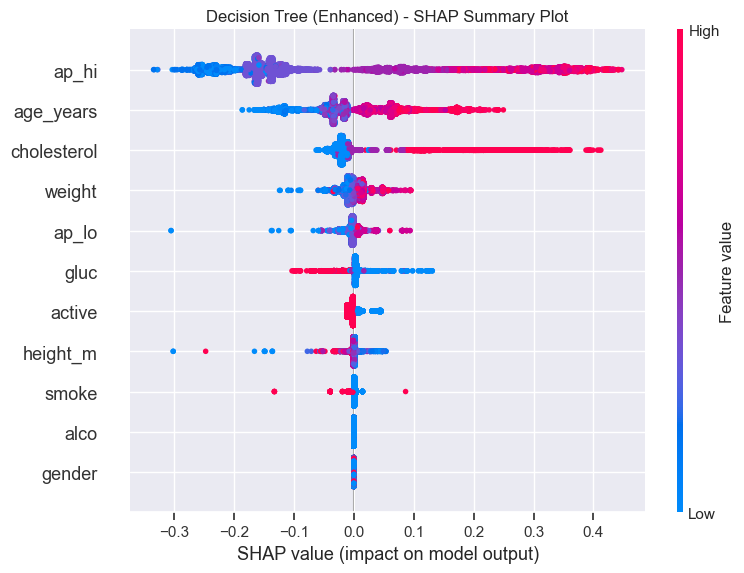

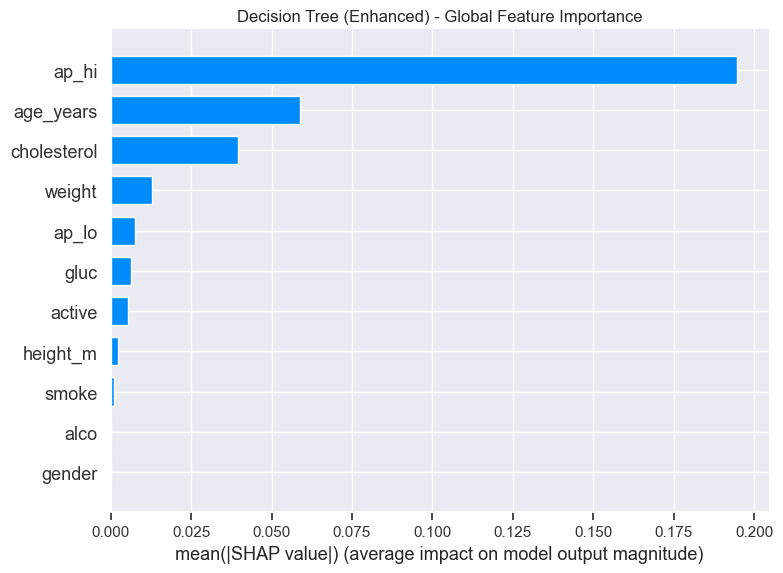


Mean absolute SHAP value by feature (global importance):


ap_hi          0.194787
age_years      0.058959
cholesterol    0.039528
weight         0.012743
ap_lo          0.007643
gluc           0.006249
active         0.005344
height_m       0.002288
smoke          0.000950
gender         0.000000
alco           0.000000
dtype: float64

In [336]:
# 1. Initialize the explainer for our Decision Tree model
# (dt_enhance is the model trained on the 'enhanced' feature set)
explainer_dt = sp.TreeExplainer(dt_base)

# 2. Calculate the "Explanation" object
# This bundles SHAP values, data, and feature names
shap_explanations = explainer_dt(Xb_test)

# 3. Generate SHAP summary plot (beeswarm)
# We pass shap_explanations[:,:,1] to get the values for class 1 (CVD)
plt.title("Decision Tree (Enhanced) - SHAP Summary Plot")
sp.summary_plot(shap_explanations[:,:,1])
plt.show()

# 4. Generate SHAP feature importance plot (bar)
plt.title("Decision Tree (Enhanced) - Global Feature Importance")
sp.summary_plot(shap_explanations[:,:,1], plot_type="bar")
plt.show()

# 5. Print mean absolute SHAP values for global feature importance
shap_values_df = pd.DataFrame(
    shap_explanations.values[:,:,1],
    columns=Xb_test.columns
)
print("\nMean absolute SHAP value by feature (global importance):")
shap_values_df.abs().mean().sort_values(ascending=False)


📊 MIDPOINT COMPARISON: Baseline vs LRI-Enhanced


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Correlation (Pred vs True)
0,Baseline (no LRI),0.7246,0.7500,0.6650,0.7050,0.7877,0.4955
1,Enhanced (with LRI),0.6883,0.7003,0.6468,0.6725,0.7476,0.4236


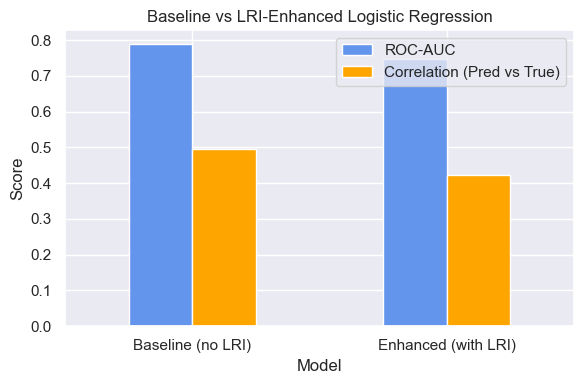

In [337]:
# --- MIDPOINT ANALYSIS: Baseline vs LRI-Enhanced Logistic Regression ---

print("\n==============================")
print("📊 MIDPOINT COMPARISON: Baseline vs LRI-Enhanced")
print("==============================")

# Define Variables for Baseline Model
scaler_base = StandardScaler()
Xb_train_scaled = scaler_base.fit_transform(Xb_train)
Xb_test_scaled = scaler_base.transform(Xb_test)

lri_baseline = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=2000,
    random_state=42
)
lri_baseline.fit(Xb_train_scaled, y_train)

y_pred_base = lri_baseline.predict(Xb_test_scaled)
y_prob_base = lri_baseline.predict_proba(Xb_test_scaled)[:, 1]
roc_base = roc_auc_score(y_test, y_prob_base)

# Define More Variables for Enhanced Model
scaler_enh = StandardScaler()
Xe_train_scaled = scaler_enh.fit_transform(Xe_train)
Xe_test_scaled = scaler_enh.transform(Xe_test)

lri_enh = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=2000,
    random_state=42
)
lri_enh.fit(Xe_train_scaled, y_train)

y_pred_enh = lri_enh.predict(Xe_test_scaled)
y_prob_enh = lri_enh.predict_proba(Xe_test_scaled)[:, 1]
roc_enh = roc_auc_score(y_test, y_prob_enh)

# --- 1. Compute metrics for both models ---
prec_base, rec_base, f1_base, _ = precision_recall_fscore_support(y_test, y_pred_base, average="binary")
prec_enh, rec_enh, f1_enh, _ = precision_recall_fscore_support(y_test, y_pred_enh, average="binary")

acc_base = accuracy_score(y_test, y_pred_base)
acc_enh  = accuracy_score(y_test, y_pred_enh)

# --- 2. Compute ROC-AUC scores (already done above, reused here) ---
# roc_base and roc_enh come from previous cells

# --- 3. Compute correlation between predicted probabilities and actual outcomes ---
corr_base = pd.DataFrame({'y_true': y_test, 'y_pred': y_prob_base}).corr().iloc[0, 1]
corr_enh  = pd.DataFrame({'y_true': y_test, 'y_pred': y_prob_enh}).corr().iloc[0, 1]

# --- 4. Build midpoint comparison DataFrame ---
midpoint_df = pd.DataFrame({
    'Model': ['Baseline (no LRI)', 'Enhanced (with LRI)'],
    'Accuracy': [acc_base, acc_enh],
    'Precision': [prec_base, prec_enh],
    'Recall': [rec_base, rec_enh],
    'F1-score': [f1_base, f1_enh],
    'ROC-AUC': [roc_base, roc_enh],
    'Correlation (Pred vs True)': [corr_base, corr_enh]
})

# --- 5. Display neatly ---
display(midpoint_df.round(4))

# --- 6. Visualize improvement ---
midpoint_df.set_index('Model')[['ROC-AUC', 'Correlation (Pred vs True)']].plot(
    kind='bar', figsize=(6,4), color=['#6495ED','#FFA500'],
    title='Baseline vs LRI-Enhanced Logistic Regression'
)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Mid-Point Analysis
While LRI is a strong indicator of cardiovascular disease (~0.14 SHAP value compared to ~0.08 for 2nd best), further analysis with SHAP shows a critical flaw:
- systolic blood pressure has a substantially higher weight than all other risk factors combined.

If so, since systolic blood pressure and age play a much larger part than other factors, how can we use SHAP to find a link between the two metrics?

How can we perhaps use this link to refine our LRI?

--- Generating SHAP Dependence Plot ---
This shows the impact of 'ap_hi' (y-axis) vs. the feature's value (x-axis)
The COLOR shows the 'age_years' of that patient.


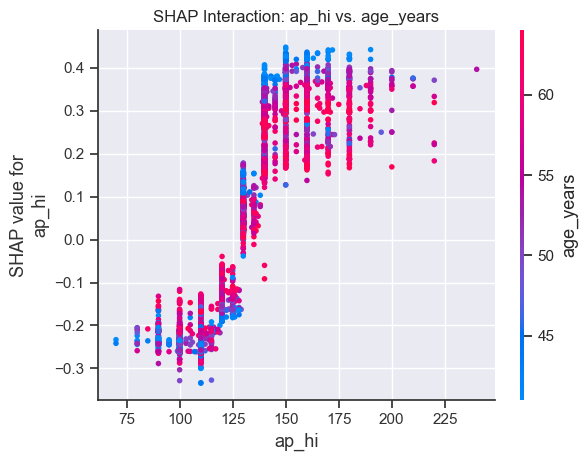

In [338]:
# --- Creative Analysis: SHAP Interaction Plot ---
#
# HYPOTHESIS: Does the risk from 'ap_hi' get worse as 'age_years' increases?
# We use our "Raw" 11-feature model for this (dt_base, Xb_test)
#
# We need the explainer and SHAP values for the 'dt_base' model
explainer_base = sp.TreeExplainer(dt_base)
shap_explanations_base = explainer_base(Xb_test)

print("--- Generating SHAP Dependence Plot ---")
print("This shows the impact of 'ap_hi' (y-axis) vs. the feature's value (x-axis)")
print("The COLOR shows the 'age_years' of that patient.")

# 1. Explicitly create one figure and one set of axes ("canvas")
fig, ax = plt.subplots() 

# 2. Set the title on *that specific canvas*
ax.set_title("SHAP Interaction: ap_hi vs. age_years")

# shap_explanations_base.values[:,:,1] = SHAP values for class 1
sp.dependence_plot(
    "ap_hi",
    shap_explanations_base.values[:,:,1], 
    Xb_test,
    interaction_index="age_years",
    ax=ax,
    show = False
)
plt.show()

This analysis proves that the relationship between blood pressure and age is complex and non-linear. The model learned a sophisticated, medically-plausible rule: high blood pressure is actually a more severe warning sign in a younger patient than it is in an older patient.

## Recalculation of LRI based on SHAP Plot Analysis to increase accuracy in predicting CVD
Using the mean SHAP values, we re-balance the initial weighted LRI, assigning new weightages to the different components of LRI. 

This new LRI will be known as SHAP-Refined LRI.



 ### Training Baseline Logistic Regression (no LRI)

=== Baseline Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.70      0.78      0.74      6940
           1       0.75      0.67      0.70      6795

    accuracy                           0.72     13735
   macro avg       0.73      0.72      0.72     13735
weighted avg       0.73      0.72      0.72     13735

ROC-AUC (Baseline): 0.788

 ### Training Enhanced Logistic Regression (with LRI)

=== Enhanced Logistic Regression Results (with LRI features) ===
              precision    recall  f1-score   support

           0       0.68      0.73      0.70      6940
           1       0.70      0.65      0.67      6795

    accuracy                           0.69     13735
   macro avg       0.69      0.69      0.69     13735
weighted avg       0.69      0.69      0.69     13735

ROC-AUC (Enhanced): 0.748

🔹 Training SHAP-Refined Logistic Regression

=== SHAP-Refined Logistic Reg

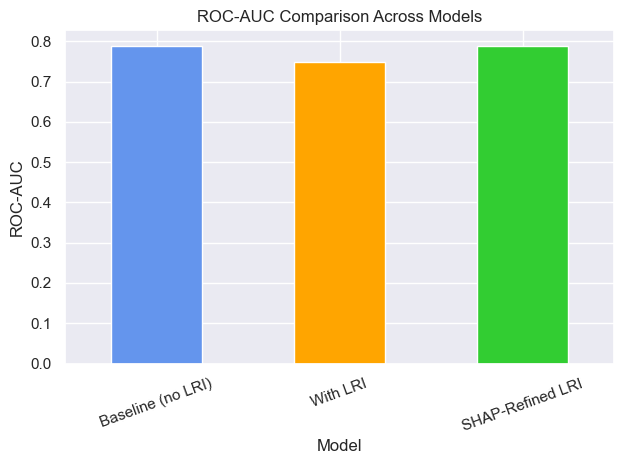


📈 CORRELATION WITH DISEASE OUTCOME
Correlation (Original LRI vs cardio): 0.423561
Correlation (SHAP-Weighted LRI vs cardio): 0.495172
✅ Correlation improved by 0.071611 after SHAP refinement.


In [339]:
# --- 1. Baseline Logistic Regression (no LRI, same features as Decision Tree baseline) ---
print(" ### Training Baseline Logistic Regression (no LRI)")

print("\n=== Baseline Logistic Regression Results ===")
print(classification_report(y_test, y_pred_base))
print(f"ROC-AUC (Baseline): {roc_base:.3f}")


# --- 2. Enhanced Logistic Regression (with original LRI features) ---
print("\n ### Training Enhanced Logistic Regression (with LRI)")

print("\n=== Enhanced Logistic Regression Results (with LRI features) ===")
print(classification_report(y_test, y_pred_enh))
print(f"ROC-AUC (Enhanced): {roc_enh:.3f}")


# --- 3. SHAP-guided refined Logistic Regression (weighted features) ---
print("\n🔹 Training SHAP-Refined Logistic Regression")

# SHAP mean importance values 
shap_means = {
    'ap_hi': 0.194787,
    'age_years': 0.058959,
    'cholesterol': 0.039528,
    'weight': 0.012743,
    'ap_lo': 0.007643,
    'gluc': 0.006249,
    'active': 0.005344,
    'height_m': 0.002288,
    'smoke': 0.000950,
    'gender': 0.000000,
    'alco': 0.000000
}

# Normalize weights
total = sum(shap_means.values())
feature_weights = {k: v / total for k, v in shap_means.items()}

Xb_train_weighted = Xb_train.copy()
Xb_test_weighted = Xb_test.copy()

for feature, weight in feature_weights.items():
    if feature in Xb_train_weighted.columns:
        Xb_train_weighted[feature] *= weight
        Xb_test_weighted[feature] *= weight

scaler_weighted = StandardScaler()
Xb_train_scaled_weighted = scaler_weighted.fit_transform(Xb_train_weighted)
Xb_test_scaled_weighted = scaler_weighted.transform(Xb_test_weighted)

lri_refined = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=2000,
    random_state=42
)
lri_refined.fit(Xb_train_scaled_weighted, y_train)

y_pred_refined = lri_refined.predict(Xb_test_scaled_weighted)
y_prob_refined = lri_refined.predict_proba(Xb_test_scaled_weighted)[:, 1]
roc_refined = roc_auc_score(y_test, y_prob_refined)

print("\n=== SHAP-Refined Logistic Regression Results ===")
print(classification_report(y_test, y_pred_refined))
print(f"ROC-AUC (SHAP-Weighted): {roc_refined:.3f}")


# --- 4. Summarize all results side-by-side ---
print("\n==============================")
print("📊 MODEL PERFORMANCE COMPARISON")
print("==============================")
print(f"Baseline ROC-AUC (no LRI):     {roc_base:.3f}")
print(f"With LRI ROC-AUC:              {roc_enh:.3f}")
print(f"SHAP-Refined LRI ROC-AUC:      {roc_refined:.3f}")

# Highlight improvement
if roc_refined > roc_enh:
    print(f"\n✅ SHAP refinement improved ROC-AUC by {roc_refined - roc_enh:.3f} over original LRI.")
else:
    print(f"\n⚠️ SHAP refinement did not improve ROC-AUC (Δ = {roc_refined - roc_enh:.3f}).")

# Visualize improvement
comparison_df = pd.DataFrame({
    'Model': ['Baseline (no LRI)', 'With LRI', 'SHAP-Refined LRI'],
    'ROC-AUC': [roc_base, roc_enh, roc_refined]
})
comparison_df.plot(
    x='Model', y='ROC-AUC', kind='bar', legend=False, color=['#6495ED','#FFA500','#32CD32'],
    title='ROC-AUC Comparison Across Models'
)
plt.ylabel('ROC-AUC')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# --- 6. Correlation between predicted LRI scores and actual disease outcome ---

# Create a temporary DataFrame to align predictions and true labels
corr_df = pd.DataFrame({
    'cardio': y_test,
    'LRI_original': y_prob_enh,
    'LRI_weighted': y_prob_refined
})

# Compute correlation coefficients
corr_original = corr_df[['LRI_original', 'cardio']].corr().iloc[0, 1]
corr_weighted = corr_df[['LRI_weighted', 'cardio']].corr().iloc[0, 1]

print("\n==============================")
print("📈 CORRELATION WITH DISEASE OUTCOME")
print("==============================")
print(f"Correlation (Original LRI vs cardio): {corr_original:.6f}")
print(f"Correlation (SHAP-Weighted LRI vs cardio): {corr_weighted:.6f}")

if corr_weighted > corr_original:
    print(f"✅ Correlation improved by {corr_weighted - corr_original:.6f} after SHAP refinement.")
else:
    print(f"⚠️ No improvement (Δ = {corr_weighted - corr_original:.6f}).")




In [340]:
# === 7. Final Combined Results Table ===

# --- Compute classification metrics for each model ---
# (using default threshold = 0.5 for fairness)
prec_base, rec_base, f1_base, _ = precision_recall_fscore_support(y_test, y_pred_base, average="binary")
prec_enh, rec_enh, f1_enh, _ = precision_recall_fscore_support(y_test, y_pred_enh, average="binary")
prec_ref, rec_ref, f1_ref, _ = precision_recall_fscore_support(y_test, y_pred_refined, average="binary")

acc_base = accuracy_score(y_test, y_pred_base)
acc_enh = accuracy_score(y_test, y_pred_enh)
acc_ref = accuracy_score(y_test, y_pred_refined)

# --- Build final summary DataFrame ---
summary_df = pd.DataFrame({
    'Model': ['Baseline (no LRI)', 'With LRI', 'SHAP-Refined LRI'],
    'Accuracy': [acc_base, acc_enh, acc_ref],
    'Precision': [prec_base, prec_enh, prec_ref],
    'Recall': [rec_base, rec_enh, rec_ref],
    'F1-score': [f1_base, f1_enh, f1_ref],
    'ROC-AUC': [roc_base, roc_enh, roc_refined],
    'Correlation (Pred vs True)': [None, corr_original, corr_weighted]
})

# --- Display neatly ---
print("\n==============================")
print("📊 FINAL METRICS COMPARISON TABLE")
print("==============================")
display(summary_df.round(4))



📊 FINAL METRICS COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Correlation (Pred vs True)
0,Baseline (no LRI),0.7246,0.7500,0.6650,0.7050,0.7877,NaN
1,With LRI,0.6883,0.7003,0.6468,0.6725,0.7476,0.4236
2,SHAP-Refined LRI,0.7230,0.7483,0.6631,0.7031,0.7876,0.4952
